# 1 · Eval Results & Behaviour  `[EVAL]`

Full-conversation outcomes **and** what the therapist actually does. Part A: outcome trajectories, the configurable PTO-vs-GRPO / K contrast, and the warmth-vs-orthogonal scorecard. Part B: behaviour drift, the rubric factor structure (is it one warmth axis?), heterogeneity by persona, and transcripts. **PTO** (pref-tree→DPO) vs **GRPO**, matched K; iteration 0 = base. Headline trio lives in `0_Headline`; exact stats in `5_Detailed_Stats`.

In [ ]:
import sys, os; sys.path.insert(0, os.path.abspath("."))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
pd.set_option("display.width", 185, "display.max_columns", 50)
import exp3
from exp3 import stats, behavior, training, pref, figures, plots
from dataclasses import asdict

# ── EDA config — edit these flat globals to control the whole notebook ─────────
cfg = exp3.EdaConfig(
    methods=None, ks=None, arm_labels=None,        # arm filter (None = all on disk)
    metrics=None, selection="all", warmth_only=False,  # metric subset / cross-model selection
    focus_arms=None, focus_metric="Q1Q2",          # default arms/metric for overlay & contrast figs
    panel=None, ncols=None, score_ylim=None, share_y=False,  # plot scales (None = inherit)
    export_group="eval",                         # results/<figures|tables>/eval/  ·  figs=PNG, tables=md+xlsx
)
S = exp3.notebook_setup(cfg)#, selection=="best")
FOCUS = cfg.focus_arms or sorted(S.SCORES.arm.unique())   # arms to show in overlay/contrast figures

In [26]:
print(FOCUS)
S_keys = asdict(S).keys()
print(S_keys) # keys: 'ARMS', 'SCORES', 'PALETTE', 'METRICS', 'ORACLE_NOISE', 'RESULTS_DIR', 'CFG'
#print(asdict(S)['ARMS'])

['GRPO_LA0', 'GRPO_LA5', 'PTO_LA0', 'PTO_LA5']
dict_keys(['ARMS', 'SCORES', 'PALETTE', 'METRICS', 'ORACLE_NOISE', 'RESULTS_DIR', 'CFG'])


## A1 · Outcome trajectories — all rubrics  `[EVAL]`
Per-rubric mean +/- 95% CI across iterations. **Read:** the warmth rubrics load on ~one factor (see §B2), so a uniform rise is one satisfaction axis; PCT/MICI/technique are the multi-skill check. Pass `arms=FOCUS` to restrict.

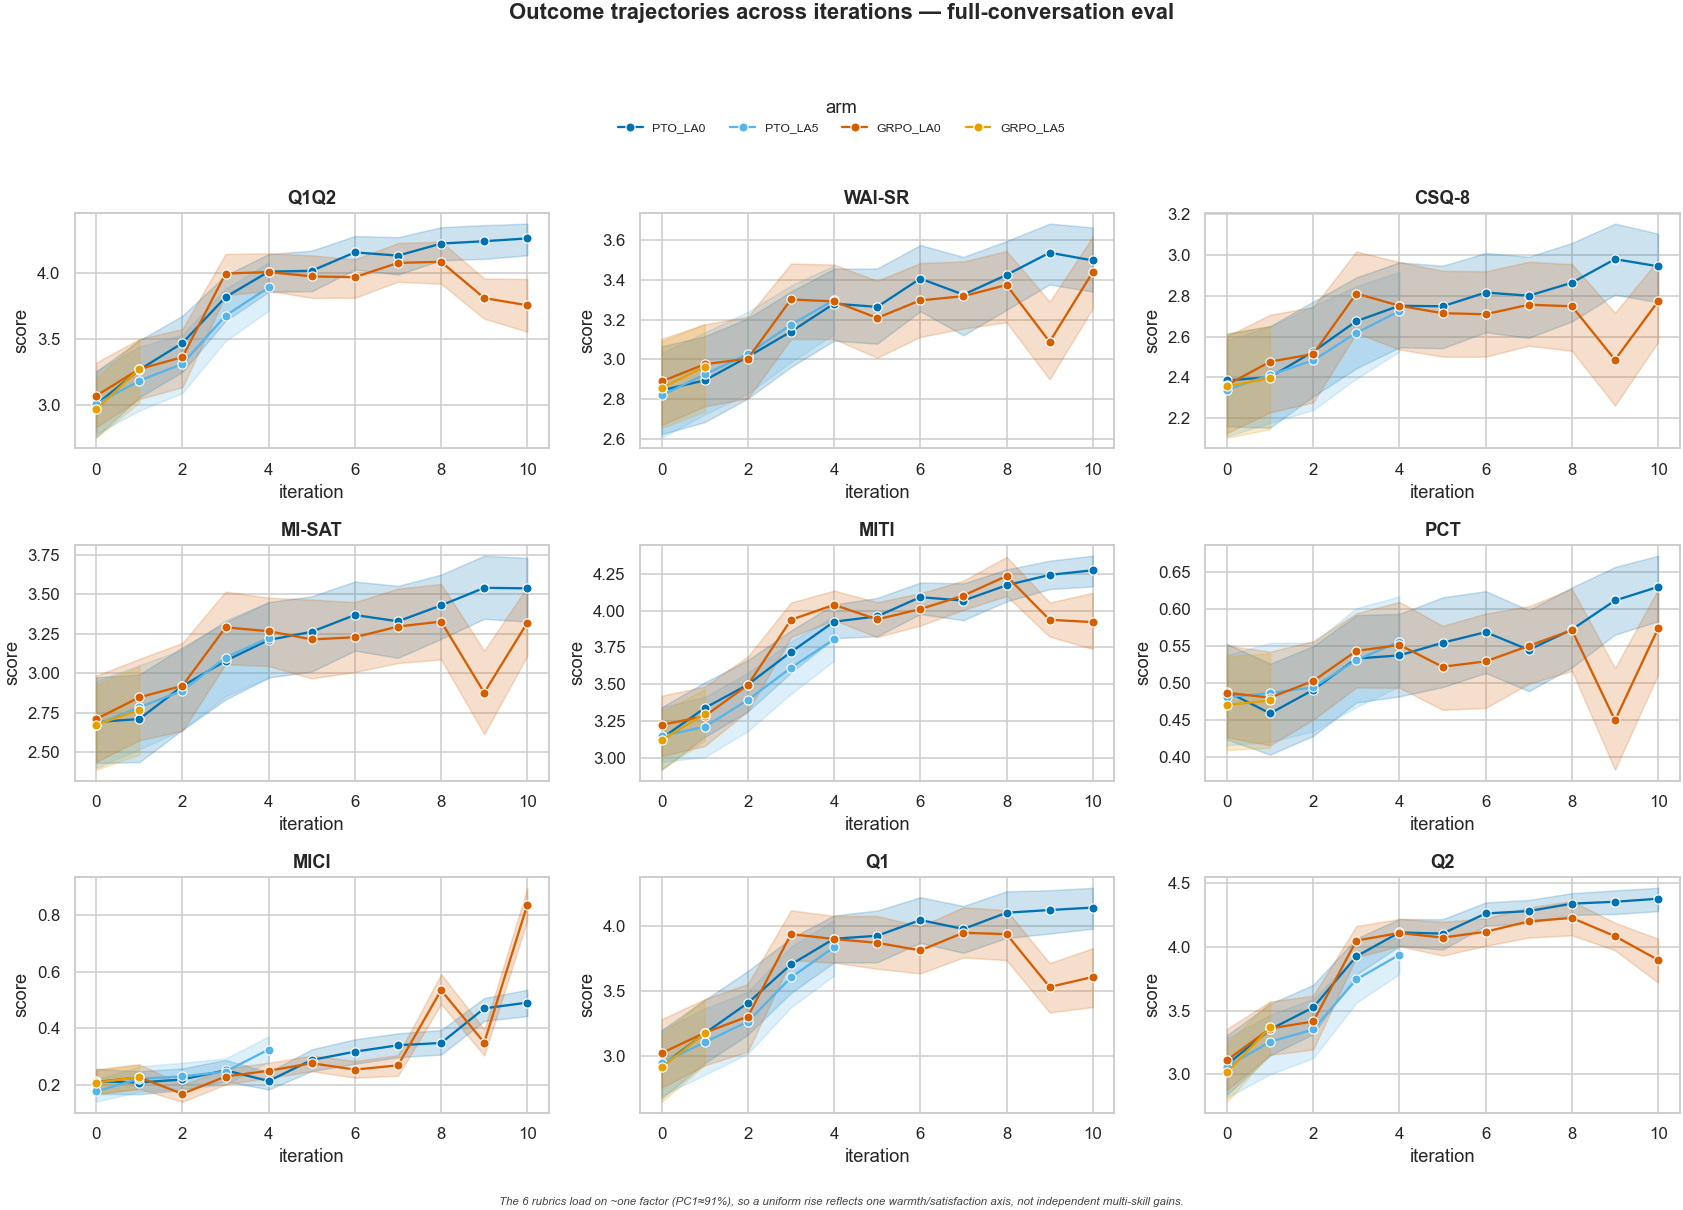

In [2]:
fig = plots.trajectory_grid(S.SCORES, palette=S.PALETTE, arms=cfg.focus_arms)
exp3.save_fig(fig, "trajectories_all_rubrics", caption="Full-conv eval: per-rubric mean +/- 95% CI across iterations, arms overlaid."); plt.show()

## A2 · Subscale trajectories  `[EVAL]`
One line per WAI/MITI sub-scale, a panel per (parent, arm).

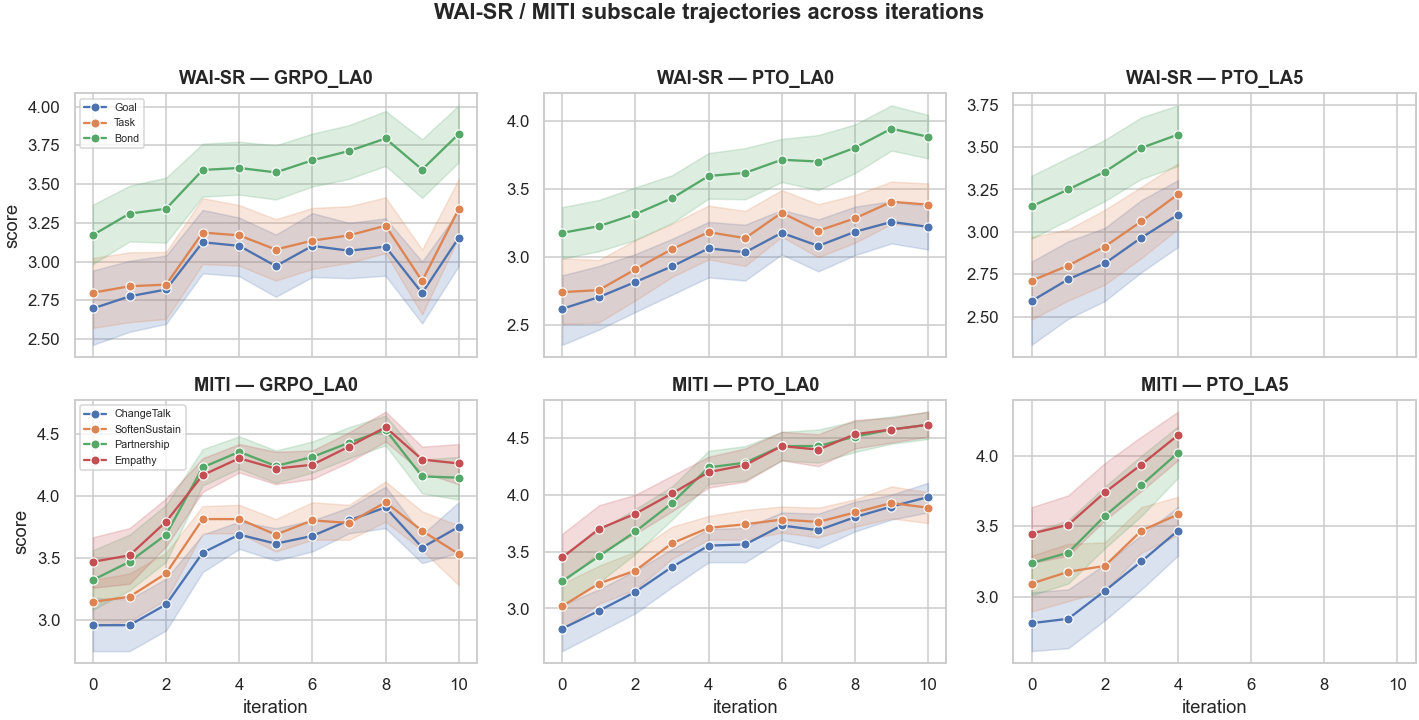

In [3]:
fig = plots.subscale_trajectory_grid(exp3.load_subscales(S.ARMS), min_iters=3)
exp3.save_fig(fig, "subscale_trajectories", caption="WAI-SR + MITI global subscale means across iterations; one panel per (parent, arm), arms with <3 scored iters omitted."); plt.show()

## A3 · Contrast — overlay any chosen arms  `[EVAL]`
**One configurable figure** (replaces the old per-K / per-method loops): edit `CONTRAST` below to overlay any arms on `cfg.focus_metric`. Examples: PTO vs GRPO at K=0; PTO K0 vs K5.

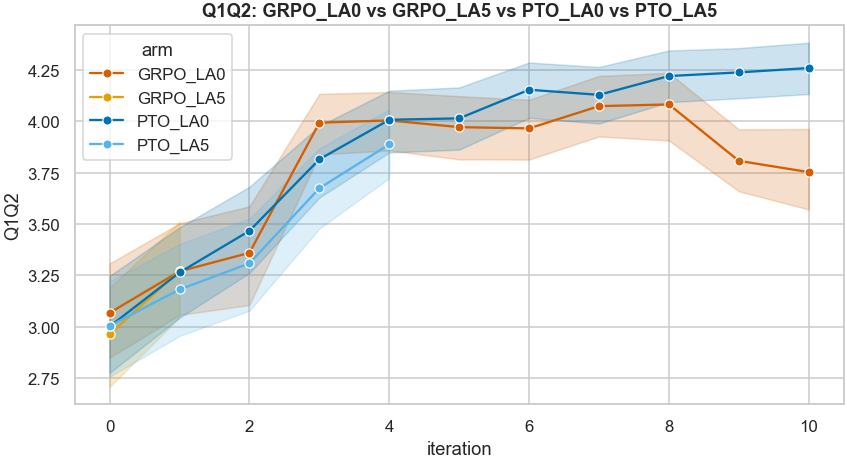

In [4]:
CONTRAST = FOCUS                      # e.g. ["PTO_LA0","GRPO_LA0"] or ["PTO_LA0","PTO_LA5"]
fig = plots.overlay_trajectory(S.SCORES, cfg.focus_metric, arms=CONTRAST, palette=S.PALETTE)
if fig is not None:
    exp3.save_fig(fig, "contrast_overlay", caption=f"{cfg.focus_metric} trajectories overlaid for {CONTRAST} (mean +/- 95% CI)."); plt.show()
else:
    print("none of", CONTRAST, "are scored.")

## A4 · Scorecard — warmth vs orthogonal axes  `[EVAL]`
Each arm's best-iteration score per metric: the warmth rubrics beside the orthogonal axes (`PCT`, `MICI ↓`, `R:Q`/`%CR`/`%MICO`). **Read:** warmth can rise while technique / patient-outcome lag — the multi-skill story the warmth rubrics hide.

In [5]:
LB = plots.leaderboard_scorecard(S.SCORES, selection="best")
display(LB)
exp3.save_table(LB, "leaderboard_scorecard", caption="Best iteration per arm: warmth rubrics beside the orthogonal axes (MICI lower-is-better, flagged ↓).")

,arm,iteration,Q1Q2,WAI-SR,CSQ-8,MI-SAT,MITI,PCT,MICI ↓,R:Q,%CR,%MICO
0,PTO_LA0,10,4.260,3.497,2.945,3.536,4.273,0.630,0.491,0.750,0.364,0.700
1,PTO_LA5,4,3.888,3.299,2.725,3.222,3.805,0.556,0.326,0.589,0.317,0.620
2,GRPO_LA0,8,4.082,3.374,2.749,3.326,4.234,0.572,0.535,1.043,0.372,0.711
3,GRPO_LA5,1,3.272,2.964,2.396,2.767,3.299,0.477,0.228,0.656,0.301,0.703


'c:\\Users\\baruc\\Desktop\\Projects\\Thesis_PTO_GRPO\\Exp3_PTO_GRPO\\eda\\results\\tables\\eval'

## A5 · Appendix — per-model outcome bars  `[EVAL]`
The exhaustive per-model bar view (all iterations, pooled Base, dotted base line).

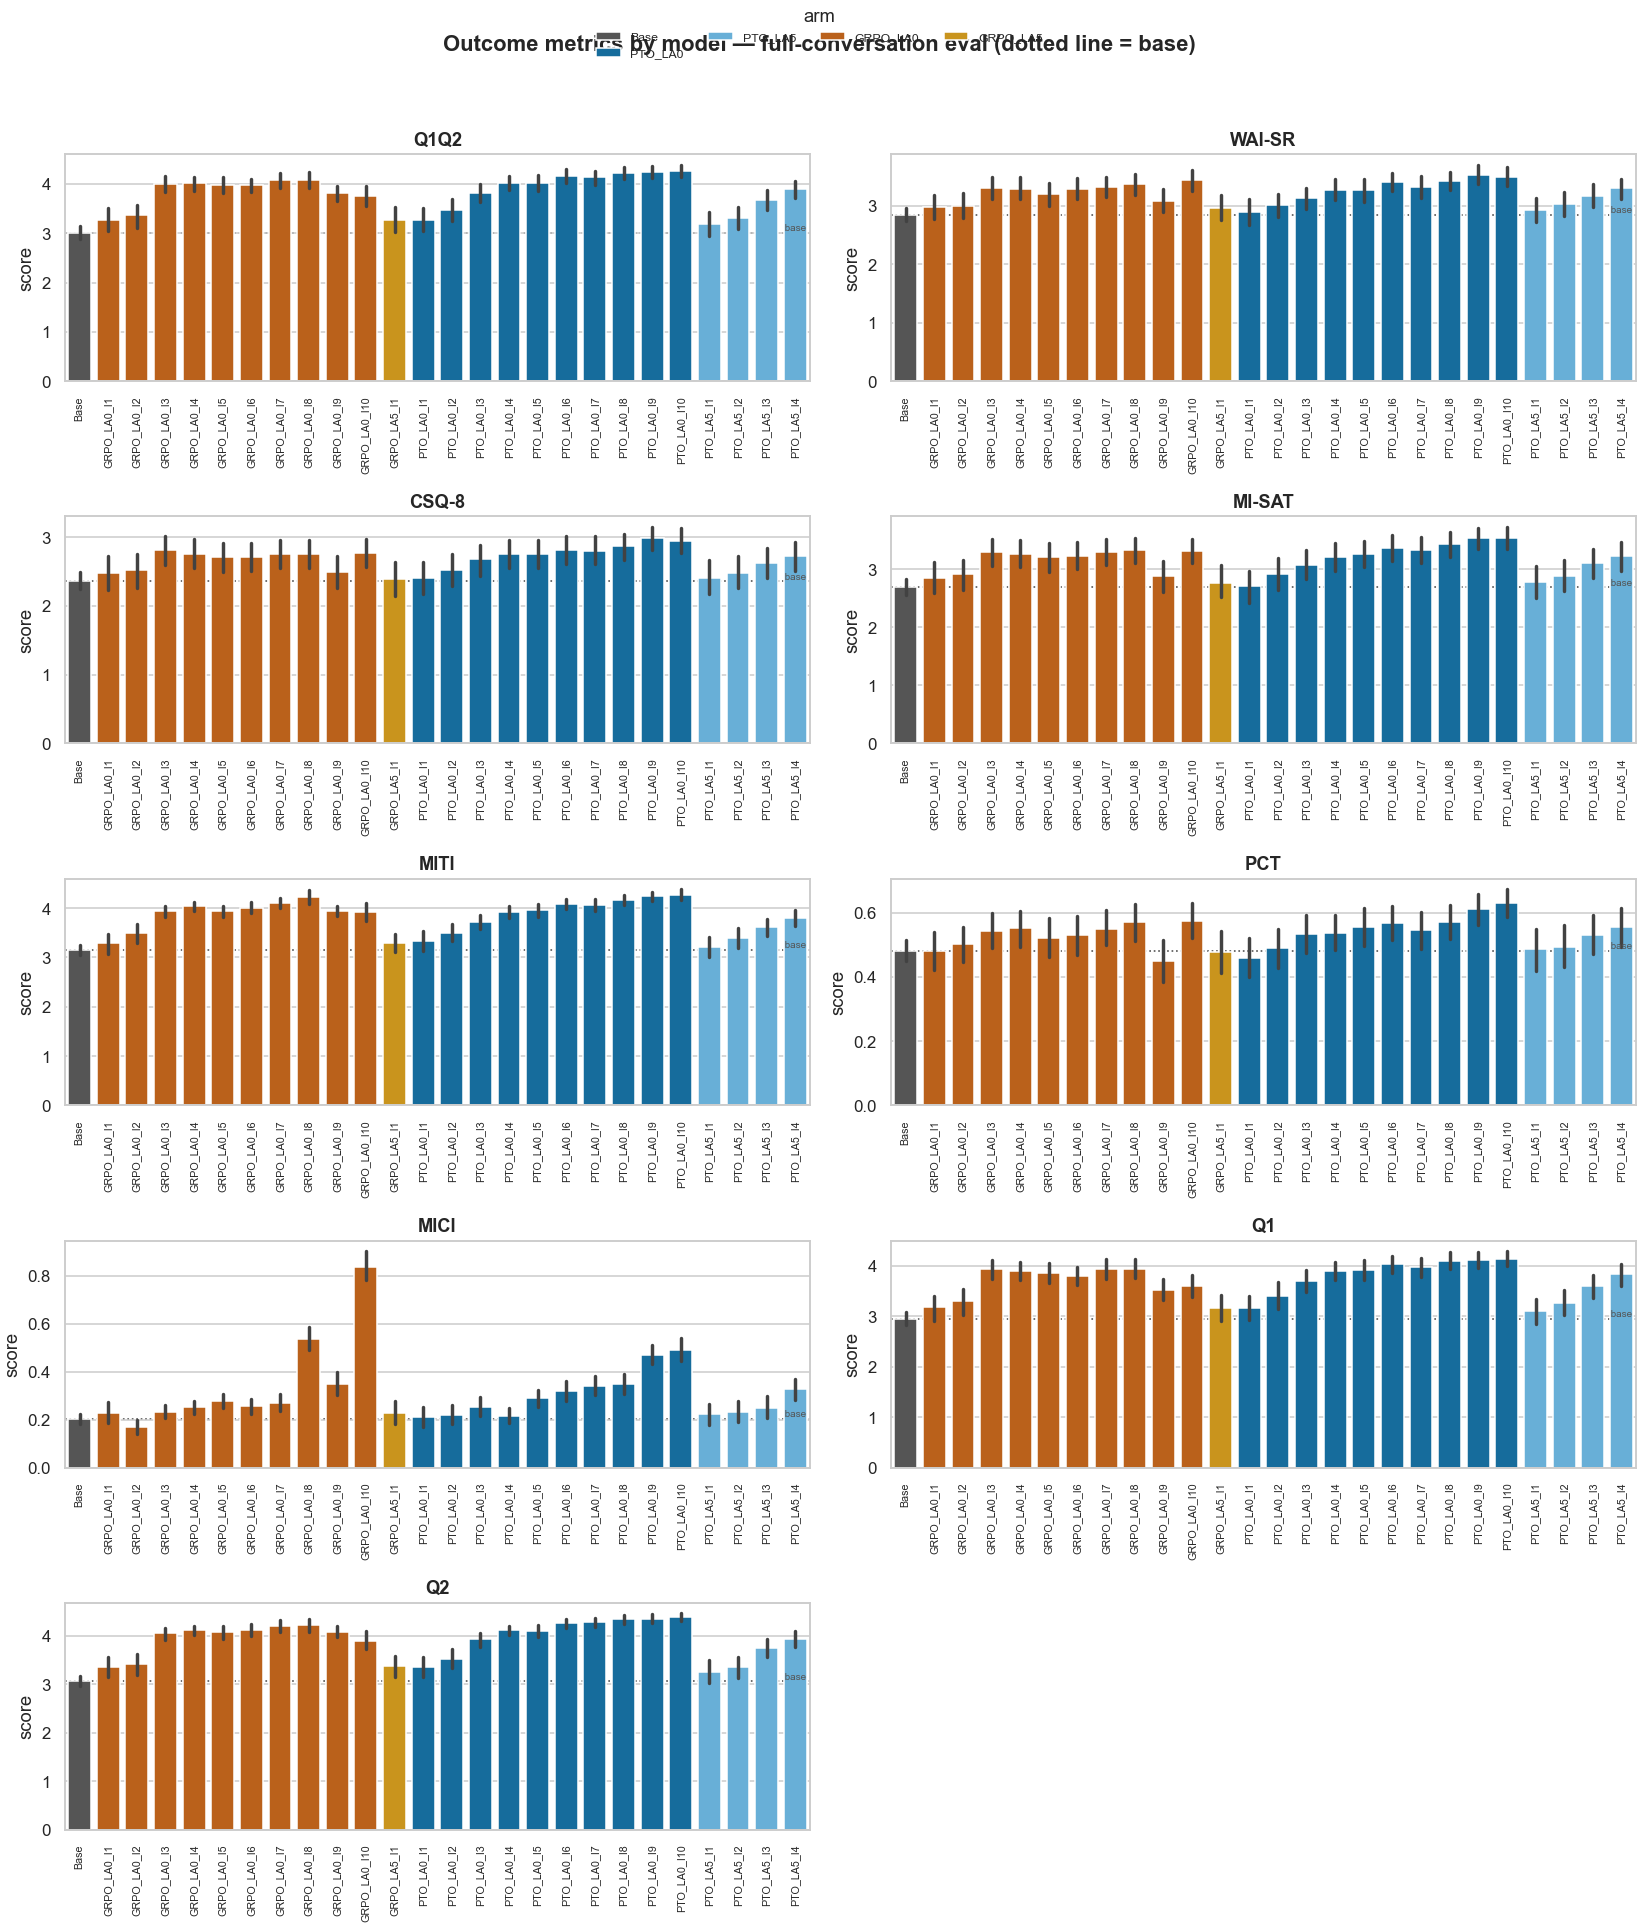

In [6]:
ALL_D = exp3.collapse_base(exp3.all_models(S.SCORES))
fig = plots.outcomes_by_model(ALL_D, palette=figures.arm_palette(sorted(ALL_D.arm.unique())), order=figures.model_order(ALL_D))
exp3.save_fig(fig, "outcomes_by_model", caption="Appendix: all models x rubrics; mean +/- 95% CI over 96 personas (arm-bases pooled into Base; dotted line = base)."); plt.show()

---
# Part B · Behaviour & Mechanism  `[EVAL]`
What the therapist *does*, and whether the score gains are real MI skill or a style shift.

In [7]:
BEH = behavior.behavior_by_iter(S.ARMS)

## 1 · Behaviour drift  `[EVAL]`
**Purpose.** MITI counts (questions B3_Q, reflections B4_SR/B5_CR, affirmations B6_AF) + text metrics
across iterations, per arm. **Read:** B6_AF + turn length rising while B3_Q falls = the
affirmation/advice drift (warmth over skill).

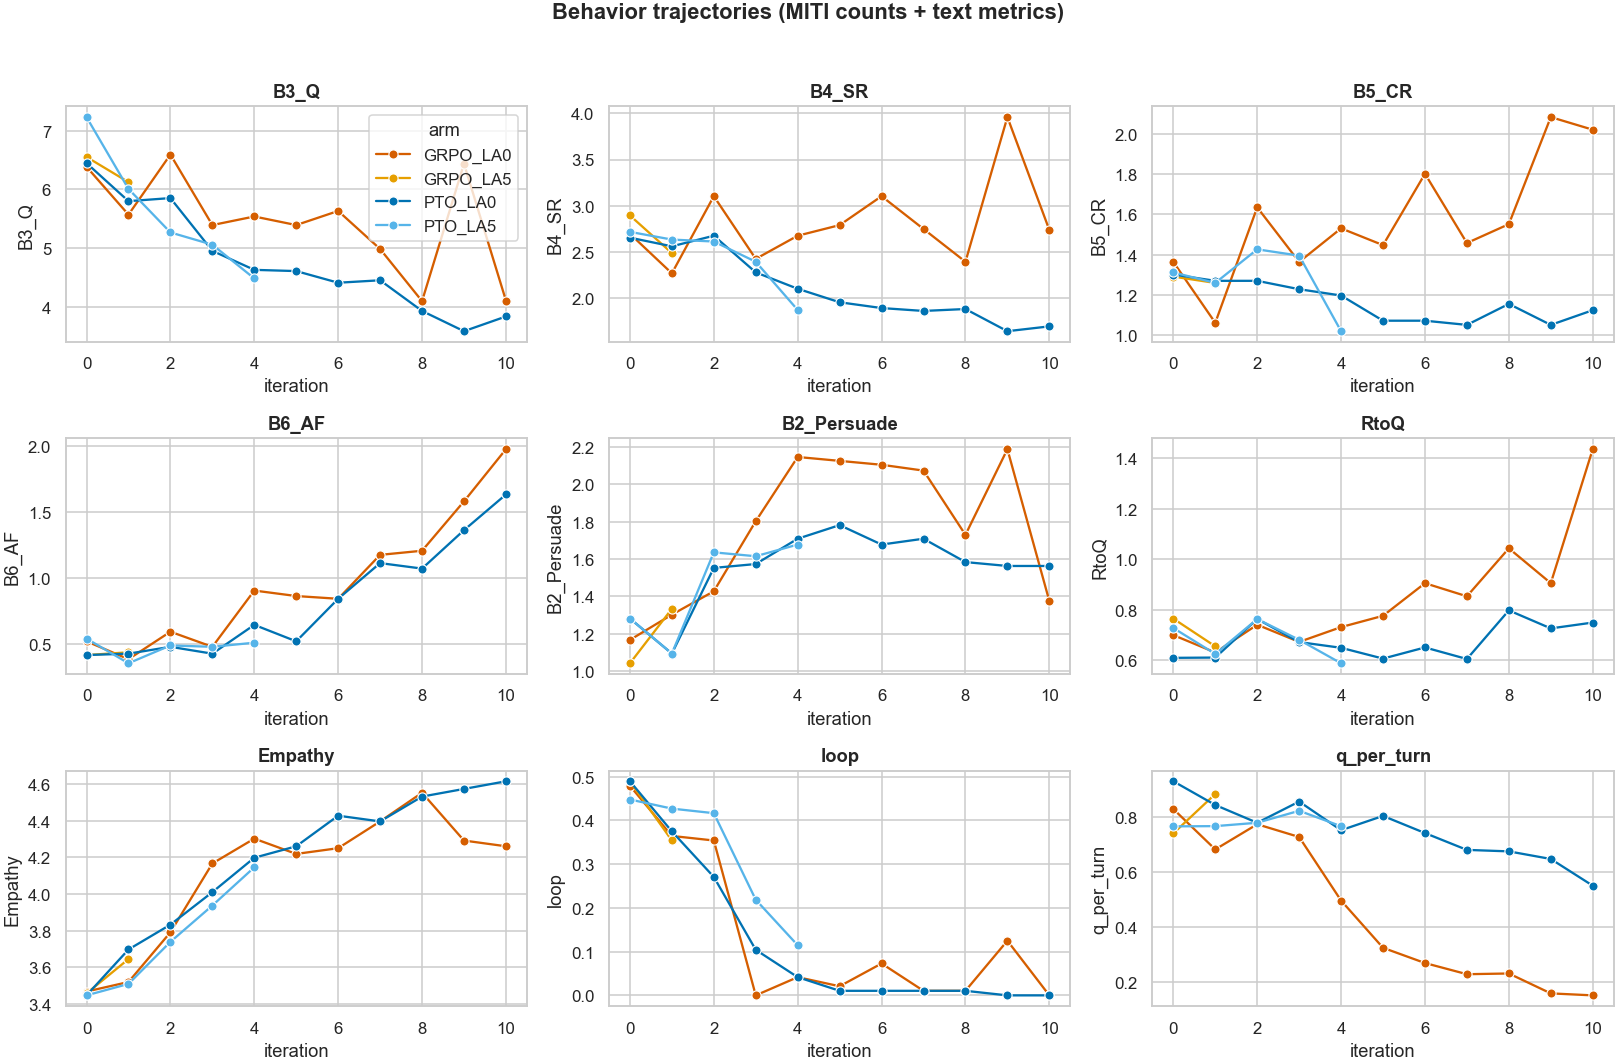


=== GRPO_LA0 behavior by iteration ===


,iteration,B3_Q,B4_SR,B5_CR,B6_AF,B2_Persuade,RtoQ,Empathy,loop,q_per_turn
0,0,6.385,2.698,1.365,0.521,1.167,0.700,3.469,0.479,0.829
1,1,5.573,2.271,1.062,0.385,1.302,0.632,3.521,0.365,0.682
2,2,6.594,3.104,1.635,0.594,1.427,0.741,3.792,0.354,0.774
3,3,5.396,2.427,1.365,0.479,1.802,0.673,4.167,0.000,0.727
4,4,5.542,2.677,1.531,0.906,2.146,0.732,4.302,0.042,0.496
5,5,5.396,2.792,1.448,0.865,2.125,0.776,4.219,0.021,0.324
6,6,5.635,3.104,1.802,0.844,2.104,0.905,4.250,0.073,0.269
7,7,4.990,2.750,1.458,1.177,2.073,0.854,4.396,0.010,0.228
8,8,4.104,2.396,1.552,1.208,1.729,1.043,4.552,0.010,0.231
9,9,6.438,3.958,2.083,1.583,2.188,0.905,4.292,0.125,0.158



=== GRPO_LA5 behavior by iteration ===


,iteration,B3_Q,B4_SR,B5_CR,B6_AF,B2_Persuade,RtoQ,Empathy,loop,q_per_turn
11,0,6.552,2.896,1.292,0.417,1.042,0.765,3.458,0.490,0.740
12,1,6.125,2.490,1.260,0.438,1.333,0.656,3.646,0.354,0.884



=== PTO_LA0 behavior by iteration ===


,iteration,B3_Q,B4_SR,B5_CR,B6_AF,B2_Persuade,RtoQ,Empathy,loop,q_per_turn
13,0,6.448,2.656,1.302,0.417,1.281,0.610,3.448,0.490,0.930
14,1,5.802,2.562,1.271,0.427,1.094,0.612,3.698,0.375,0.844
15,2,5.854,2.677,1.271,0.479,1.552,0.764,3.833,0.271,0.779
16,3,4.958,2.281,1.229,0.427,1.573,0.673,4.010,0.104,0.856
17,4,4.635,2.104,1.198,0.646,1.708,0.650,4.198,0.042,0.752
18,5,4.615,1.958,1.073,0.521,1.781,0.607,4.260,0.010,0.804
19,6,4.417,1.896,1.073,0.844,1.677,0.652,4.427,0.010,0.742
20,7,4.458,1.865,1.052,1.115,1.708,0.606,4.396,0.010,0.680
21,8,3.938,1.885,1.156,1.073,1.583,0.798,4.531,0.010,0.675
22,9,3.594,1.646,1.052,1.365,1.562,0.727,4.573,0.000,0.647



=== PTO_LA5 behavior by iteration ===


,iteration,B3_Q,B4_SR,B5_CR,B6_AF,B2_Persuade,RtoQ,Empathy,loop,q_per_turn
24,0,7.229,2.719,1.312,0.542,1.281,0.728,3.448,0.448,0.766
25,1,6.010,2.635,1.260,0.354,1.094,0.626,3.510,0.427,0.767
26,2,5.271,2.615,1.427,0.490,1.635,0.764,3.740,0.417,0.779
27,3,5.062,2.396,1.396,0.479,1.615,0.682,3.938,0.219,0.823
28,4,4.490,1.875,1.021,0.510,1.677,0.589,4.146,0.115,0.766


In [8]:
fig = plots.behavior_trajectory_grid(BEH)
if fig: exp3.save_fig(fig, "behavior_drift", caption="MITI behavior counts (B3_Q questions, B4_SR/B5_CR reflections, B6_AF affirmations, B2_Persuade) + text metrics across iterations, all arms."); plt.show()
# NOTE: the semantic affirmation signal is the oracle-coded B6_AF (and, once MICI is scored,
# MICI_OverPraiseRate) — the old brittle `affirm_rate` regex is demoted to a sanity-check (see §7).
BM = [m for m in ["B3_Q", "B4_SR", "B5_CR", "B6_AF", "B2_Persuade", "RtoQ", "Empathy", "loop", "q_per_turn"] if m in BEH.columns]
for arm in sorted(BEH.arm.unique()):
    BT = BEH[BEH.arm == arm][["iteration"] + BM].round(3)
    print(f"\n=== {arm} behavior by iteration ==="); display(BT)
    exp3.save_table(BT, f"{arm}_behavior_by_iter", caption=f"{arm} mean behavior metrics per iteration (MITI counts + text metrics).")

## 2 · Rubric factor structure  `[EVAL]`
**Purpose.** Are the rubrics independent skills or one warmth halo? Inter-rubric correlation + PC1 share.
The 5 satisfaction/alliance rubrics (Q1Q2, WAI-SR, CSQ-8, MI-SAT, MITI-global) historically collapse to
**one factor (PC1≈91%)** — "all rubrics up" is one latent warmth axis, not multi-skill gain. Here we add
**orthogonal axes** meant to load OFF that factor: the *free* objective MITI-proficiency ratios
(`R:Q`, `%CR`, `%MICO`, derived from existing behavior counts — no rescoring) and, once scored, the new
`PCT` (patient change-talk proportion) and `MICI` (MI-inconsistent rate, **lower = better**) oracle
questionnaires. **Read:** if the new axes have near-zero PC1 loadings and form a second factor, the
expanded battery is genuinely more informative. (Reward faithfulness lives in `3_Reward_Reliability`.)

metrics in correlation/PCA: ['Q1Q2', 'WAI-SR', 'CSQ-8', 'MI-SAT', 'MITI', 'PCT', 'MICI', 'R:Q', '%CR', '%MICO']


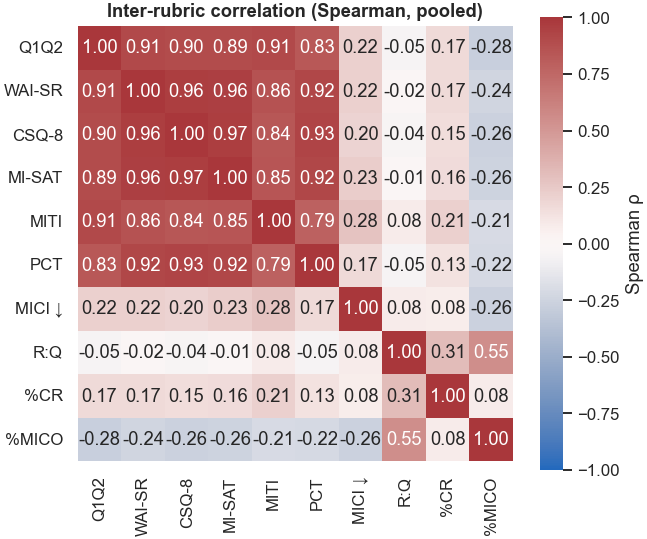


POOLED: PC1 = 55.4%  (over 10 metrics: ['Q1Q2', 'WAI-SR', 'CSQ-8', 'MI-SAT', 'MITI', 'PCT', 'MICI', 'R:Q', '%CR', '%MICO'])
        PC1 loadings = {'Q1Q2': 0.403, 'WAI-SR': 0.409, 'CSQ-8': 0.41, 'MI-SAT': 0.415, 'MITI': 0.385, 'PCT': 0.395, 'MICI': 0.072, 'R:Q': -0.049, '%CR': 0.049, '%MICO': -0.124}
        -> warmth rubrics load ~equally on PC1; near-zero loadings = orthogonal axis.
GRPO_LA0: PC1 = 55.0%  loadings={'Q1Q2': 0.402, 'WAI-SR': 0.41, 'CSQ-8': 0.412, 'MI-SAT': 0.416, 'MITI': 0.382, 'PCT': 0.4, 'MICI': 0.09, 'R:Q': -0.015, '%CR': 0.042, '%MICO': -0.105}
GRPO_LA5: PC1 = 58.0%  loadings={'Q1Q2': 0.4, 'WAI-SR': 0.402, 'CSQ-8': 0.405, 'MI-SAT': 0.407, 'MITI': 0.397, 'PCT': 0.381, 'MICI': 0.034, 'R:Q': -0.059, '%CR': 0.093, '%MICO': -0.182}
PTO_LA0: PC1 = 55.6%  loadings={'Q1Q2': 0.404, 'WAI-SR': 0.408, 'CSQ-8': 0.408, 'MI-SAT': 0.414, 'MITI': 0.38, 'PCT': 0.397, 'MICI': 0.051, 'R:Q': -0.087, '%CR': 0.007, '%MICO': -0.144}
PTO_LA5: PC1 = 56.7%  loadings={'Q1Q2': 0.406, 'WAI-SR'

In [9]:
# Expand the scores with the FREE objective MITI-proficiency ratios (+ PCT/MICI if already scored).
SCO = exp3.add_derived_mitiprof_rows(S.SCORES, S.ARMS)
EXPANDED = [m for m in (exp3.WARMTH_RUBRICS + exp3.ORTHOGONAL_METRICS)
            if m in SCO.questionnaire.unique()]
print("metrics in correlation/PCA:", EXPANDED)

# Inter-rubric correlation over the EXPANDED set (warmth rubrics + orthogonal axes).
fig = plots.rubric_correlation_heatmap(SCO, metrics=EXPANDED)
exp3.save_fig(fig, "rubric_correlation", caption="Spearman correlation among rubric + orthogonal-axis scores (per conversation, pooled). The warmth rubrics block together; R:Q/%CR/%MICO/PCT/MICI should sit apart."); plt.show()

# PCA: pooled + per arm. Does adding orthogonal axes drop the dominant PC1 share?
pca_all = stats.rubric_pca(SCO, metrics=EXPANDED)
if pca_all["explained_variance_ratio"]:
    print(f"\nPOOLED: PC1 = {pca_all['explained_variance_ratio'][0]:.1%}  "
          f"(over {len(pca_all['metrics'])} metrics: {pca_all['metrics']})")
    print(f"        PC1 loadings = {pca_all['pc1_loadings']}")
    print("        -> warmth rubrics load ~equally on PC1; near-zero loadings = orthogonal axis.")
for arm in sorted(SCO.arm.unique()):
    p = stats.rubric_pca(SCO[SCO.arm == arm], metrics=EXPANDED)
    if p["explained_variance_ratio"]:
        print(f"{arm}: PC1 = {p['explained_variance_ratio'][0]:.1%}  loadings={p['pc1_loadings']}")

### What PC1 measures — factor loadings  `[EVAL]`
Each metric's loading on the principal components. The 5 warmth rubrics all load high on **PC1** (~0.44 each) → they are essentially **one** 'good warm therapist' factor. The orthogonal axes (R:Q/%CR/%MICO, PCT, MICI) load ~0 on PC1 and instead define **PC2** — i.e. they measure something the warmth rubrics don't. That's the whole point of adding them.

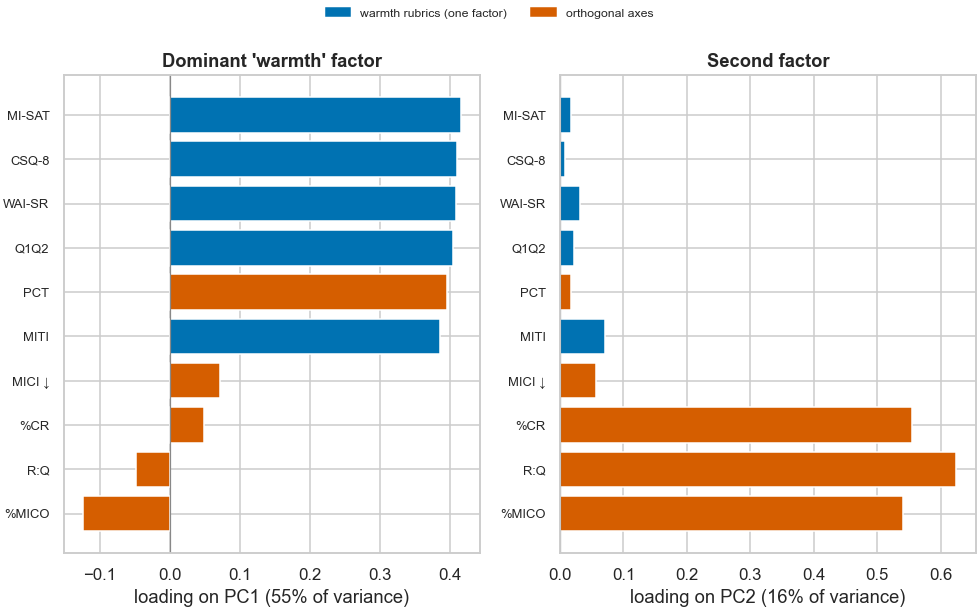

In [10]:
fig = plots.factor_loadings_bars(SCO, metrics=EXPANDED, components=("PC1","PC2"))
if fig is not None:
    exp3.save_fig(fig, "factor_loadings", caption="Each metric's PCA loading: the 5 warmth rubrics load high on PC1 (one shared factor); the orthogonal axes load ~0 on PC1 and define PC2."); plt.show()
else:
    print("factor loadings need >=2 metrics with enough rows.")

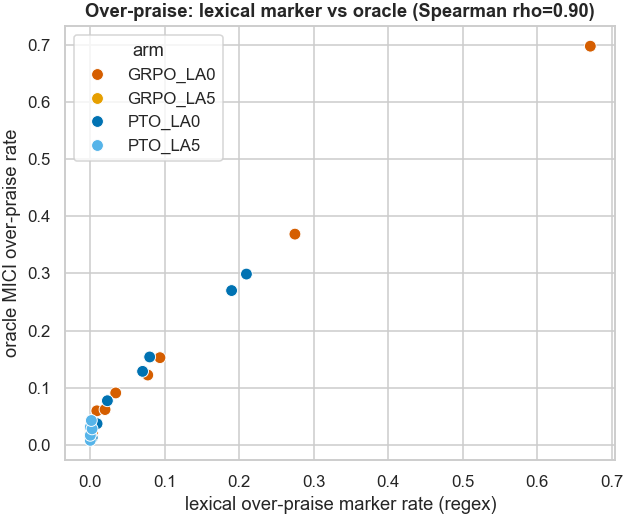

In [11]:
# Over-praise cross-check: deterministic lexical marker rate vs the oracle's MICI_OverPraiseRate.
# Validates the DIRECTION of the demoted regex against the professional coder (same role loop% plays
# for degeneration). Empty until the MICI questionnaire is scored via Run_Eval.
XC = behavior.overpraise_crosscheck(S.ARMS)
if XC.empty:
    print("MICI not scored yet — run Run_Eval.ipynb with QUESTIONNAIRE_FILTER=['PCT','MICI'] to populate this cross-check.")
else:
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.scatterplot(XC, x="lex_overpraise_marker_rate", y="MICI_OverPraiseRate",
                    hue="arm", palette=figures.arm_palette(sorted(XC.arm.unique())), s=60, ax=ax)
    rho = XC[["lex_overpraise_marker_rate", "MICI_OverPraiseRate"]].corr(method="spearman").iloc[0, 1]
    ax.set_title(f"Over-praise: lexical marker vs oracle (Spearman rho={rho:.2f})")
    ax.set_xlabel("lexical over-praise marker rate (regex)"); ax.set_ylabel("oracle MICI over-praise rate")
    fig.tight_layout()
    exp3.save_fig(fig, "overpraise_crosscheck", caption="Per-(arm,iteration) deterministic lexical over-praise marker rate vs the oracle-coded MICI over-praise rate — a directional sanity-check on the demoted regex."); plt.show()

## 3 · Heterogeneity by true persona  `[EVAL]`
Does the gain depend on who the patient is? One small-multiples figure per trait (a panel per arm) — restrict with `arms=cfg.focus_arms`. Exploratory.

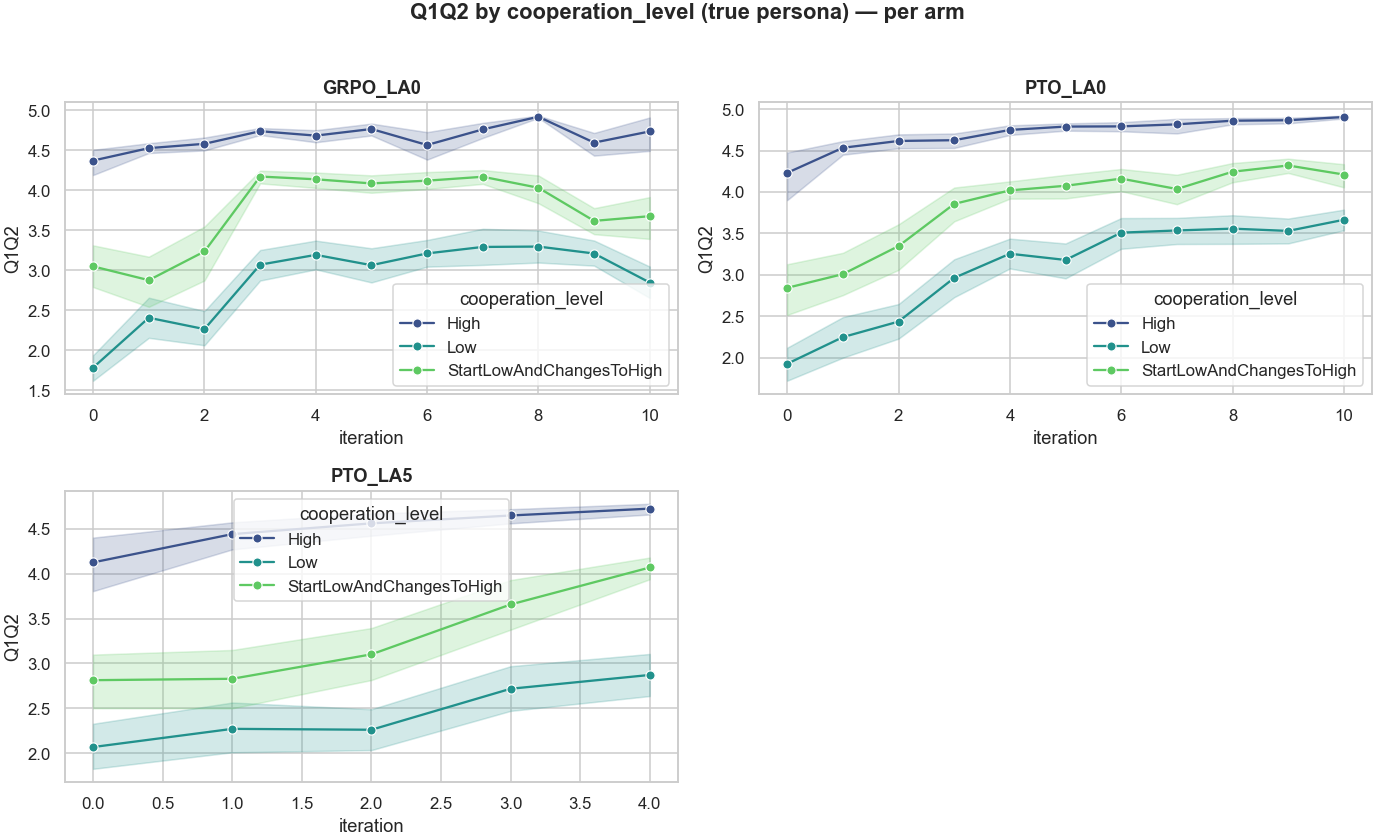

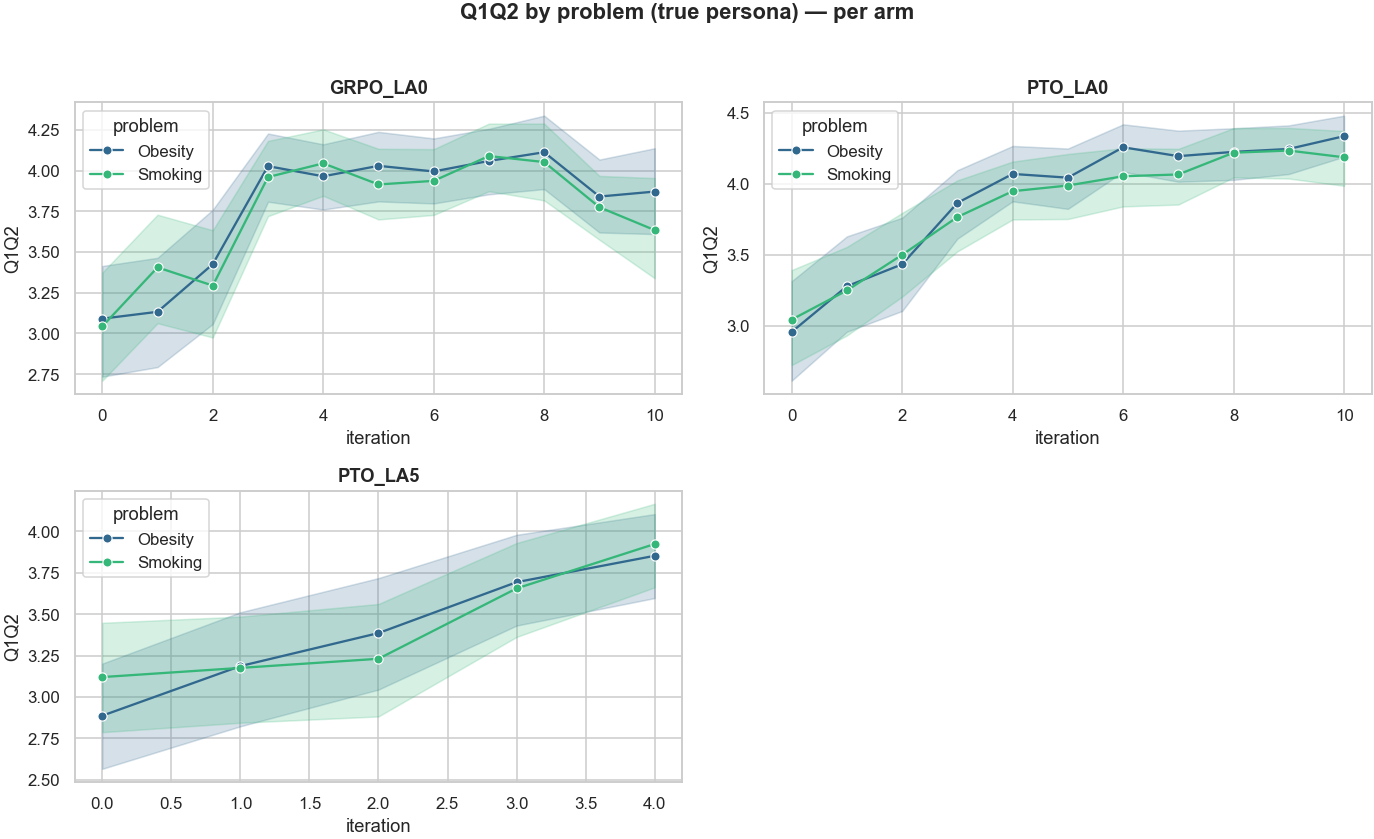

In [12]:
for HET_CHAR in ["cooperation_level", "problem"]:
    fig = plots.heterogeneity_grid(S.SCORES, HET_CHAR, arms=cfg.focus_arms, metric=cfg.focus_metric)
    if fig is None: print(f"{HET_CHAR}: nothing plottable yet."); continue
    exp3.save_fig(fig, f"heterogeneity_{HET_CHAR}", caption=f"{cfg.focus_metric} across iterations split by true patient {HET_CHAR}; one panel per arm."); plt.show()

## 4 · Session end + length  `[EVAL]`
**Purpose.** Mean conversation length across iterations + how sessions terminate. **Read:** rising
length tracks the advice drift; the end-reason mix is a degeneration health-check.

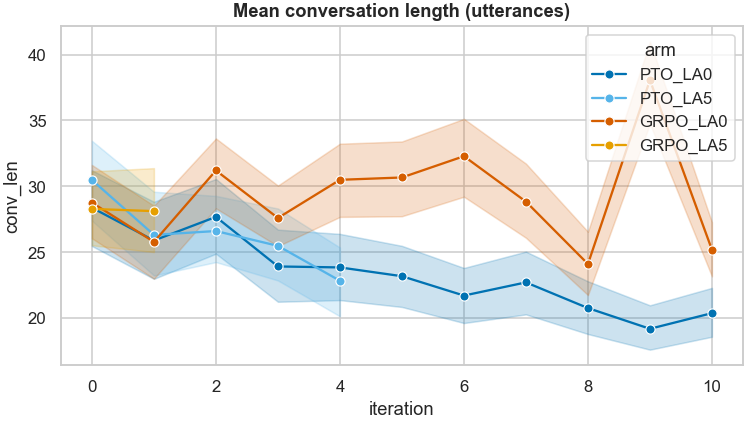

ended_by,nan,patient,therapist
arm,,,
GRPO_LA0,260.0,793.0,3.0
GRPO_LA5,61.0,128.0,3.0
PTO_LA0,178.0,871.0,7.0
PTO_LA5,127.0,349.0,4.0


In [13]:
TEXT = behavior.text_metrics(S.ARMS, attach_persona=False)
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(TEXT, x="iteration", y="conv_len", hue="arm", palette=figures.arm_palette(sorted(TEXT.arm.unique())), marker="o", ax=ax)
ax.set_title("Mean conversation length (utterances)"); plt.show()
rows = []
for a in S.ARMS:
    for k in a.iters:
        cdir = a.conv_dir(k)
        for fn in (os.listdir(cdir) if cdir and os.path.isdir(cdir) else []):
            if fn.startswith("conversation_") and fn.endswith(".csv"):
                try: dd = pd.read_csv(os.path.join(cdir, fn))
                except Exception: continue
                rows.append({"arm": a.label, "ended_by": str(dd["session_ended_by"].iloc[0]) if "session_ended_by" in dd else "NA"})
if rows:
    display(pd.DataFrame(rows).groupby(["arm", "ended_by"]).size().rename("n").reset_index()
            .pivot_table(index="arm", columns="ended_by", values="n", fill_value=0))

## 5 · Persona-matched transcripts  `[EVAL]`
**Purpose.** The same patient persona's conversation early / mid / late per arm — the qualitative drift
in actual words (true-persona recovery makes the match exact across the per-iteration shuffle).

In [14]:
from exp3.personas import persona_order
def file_of_persona(seed, k, pid, n=96): return persona_order(seed, k, n).index(pid)
PERSONA = 0
print("persona", PERSONA, "=", exp3.canonical_personas().loc[PERSONA].to_dict(), "\n")
for arm in S.ARMS:
    iters = arm.iters
    pick = sorted(set([iters[0], iters[len(iters) // 2], iters[-1]]))
    print(f"\n############  {arm.label}  ############")
    for k in pick:
        cdir = arm.conv_dir(k)
        if not cdir: continue
        fi = file_of_persona(arm.seed, k, PERSONA)
        fp = os.path.join(cdir, f"conversation_{fi}.csv")
        if not os.path.exists(fp): continue
        d = pd.read_csv(fp); th = d[d.role == "therapist"]["conversation"].astype(str).tolist()
        print(f"==== {arm.label} model_iter_{k} (conv_{fi}) — {len(th)} therapist turns ====")
        for t in th[1:4]:
            print("   •", " ".join(t.split())[:240]); print()

persona 0 = {'gender': 'Male', 'age_value': 27, 'problem': 'Smoking', 'problem_time': 'FewMonths', 'tried_to_solve': 'Never', 'cooperation_level': 'Low'} 


############  PTO_LA0  ############
==== PTO_LA0 model_iter_0 (conv_14) — 10 therapist turns ====
   • I can understand that. Let's talk about your goals. What's the point of this session?

   • OK, so why don't we start by talking about what it is you enjoy about smoking?

   • I can see that. So what do you enjoy about it? Are there any specific activities you like to do?

==== PTO_LA0 model_iter_5 (conv_54) — 8 therapist turns ====
   • Oh, right, well that’s ok. Let’s talk about what motivates you to want to stop smoking. What do you see as the biggest barrier to doing so?

   • That’s fair. So, how do you want to approach this conversation? What would you like to achieve from our time together?

   • Oh, I totally understand. I can relate to that. I’m here to help you understand why quitting smoking is important and how you ca

## 6 · How to read this notebook
- The **affirmation-drift** signature (B6_AF + turn length up, B3_Q down, §1) is the warmth-over-skill flag — compare PTO vs GRPO onset at matched late iters.
- **Factor structure** (§2): the 5 warmth rubrics share a dominant **PC1** (≈91% alone), so "all rubrics up" is weak multi-skill evidence. The added **orthogonal axes** (R:Q / %CR / %MICO objective ratios — free; plus PCT / MICI once scored) should load OFF PC1 and drop its share — that's what makes the expanded battery informative. MICI is **lower-is-better**; the over-praise cross-check validates the demoted regex against the oracle.
- **Heterogeneity** (§3) shows which personas benefit; **transcripts** (§5) are the ground truth.
- _(Reward faithfulness → `3`; exact stats → `5`.)_